<a href="https://colab.research.google.com/github/JSEFERINO/Archivos-DOE-2026/blob/main/Dise%C3%B1o_de_Experimentos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

David Martinez T00061641

--- PROMEDIOS POR MÉTODO ---
        Total  Promedio
Metodo                 
A          30      7.50
B          36      9.00
C          51     12.75
D          43     10.75


--- TABLA ANOVA ---
             sum_sq   df      F    PR(>F)
C(Metodo)      61.5  3.0  10.25  0.002919
C(Operador)    28.5  3.0   4.75  0.029846
Residual       18.0  9.0    NaN       NaN


--- PRUEBA HSD DE TUKEY (alpha = 0.05) ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B      1.5  0.709 -2.6325 5.6325  False
     A      C     5.25 0.0123  1.1175 9.3825   True
     A      D     3.25 0.1443 -0.8825 7.3825  False
     B      C     3.75 0.0799 -0.3825 7.8825  False
     B      D     1.75 0.6049 -2.3825 5.8825  False
     C      D     -2.0 0.5019 -6.1325 2.1325  False
---------------------------------------------------




/tmp/ipykernel_1071/1370426201.py:50: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(ax=axes[0], data=df, x='Metodo', y='Tiempo', errorbar=('ci', 95), capsize=.1, join=False, color='b')
/tmp/ipykernel_1071/1370426201.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df, x='Metodo', y='Tiempo', palette="Set2")


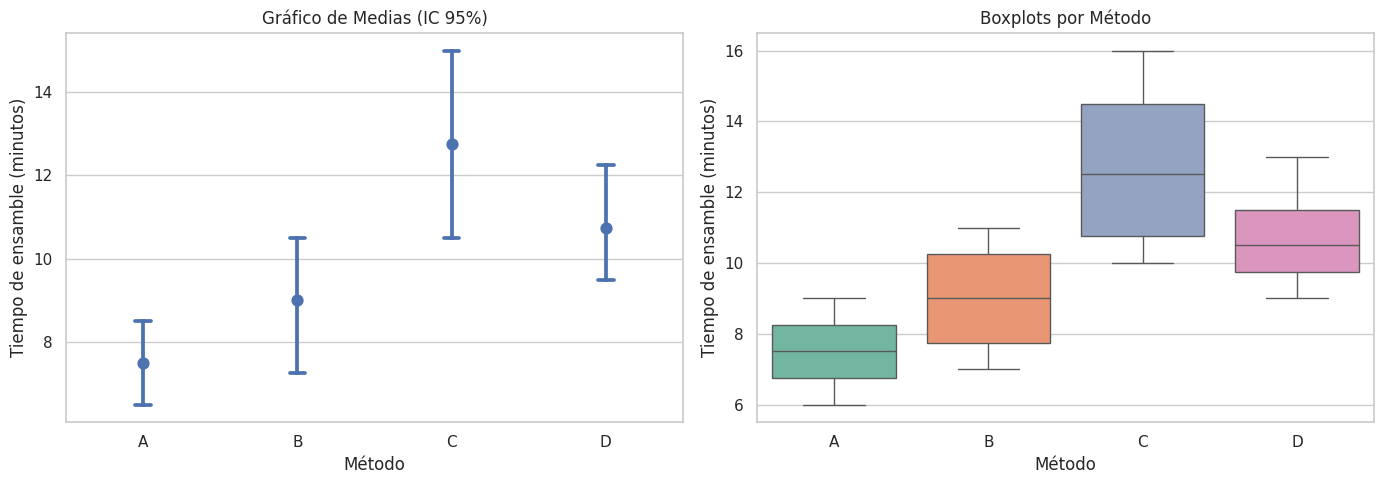

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. DATOS DEL EXPERIMENTO (Sección 3 de la imagen)
data = {
    'Operador': ['1', '2', '3', '4'] * 4, # Bloques
    'Metodo': ['A']*4 + ['B']*4 + ['C']*4 + ['D']*4, # Tratamientos
    'Tiempo': [
        6, 9, 7, 8,    # Método A
        7, 10, 11, 8,  # Método B
        10, 16, 11, 14,# Método C
        10, 13, 11, 9  # Método D
    ]
}

df = pd.DataFrame(data)

# 2. PROMEDIOS POR MÉTODO (Sección 7)
print("--- PROMEDIOS POR MÉTODO ---")
promedios = df.groupby('Metodo')['Tiempo'].agg(['sum', 'mean']).rename(columns={'sum':'Total', 'mean':'Promedio'})
print(promedios)
print("\n")

# 3. TABLA ANOVA (Secciones 4, 5 y 6)
# Ajustamos el modelo lineal ordinario (OLS)
modelo = ols('Tiempo ~ C(Metodo) + C(Operador)', data=df).fit()
anova_tabla = sm.stats.anova_lm(modelo, typ=2)

print("--- TABLA ANOVA ---")
print(anova_tabla)
print("\n")

# 4. PRUEBA HSD DE TUKEY (Sección 10)
print("--- PRUEBA HSD DE TUKEY (alpha = 0.05) ---")
tukey = pairwise_tukeyhsd(endog=df['Tiempo'], groups=df['Metodo'], alpha=0.05)
print(tukey)
print("\n")

# 5. GRÁFICOS (Secciones 8 y 9)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Medias (Intervalo de Confianza 95%)
sns.pointplot(ax=axes[0], data=df, x='Metodo', y='Tiempo', errorbar=('ci', 95), capsize=.1, join=False, color='b')
axes[0].set_title('Gráfico de Medias (IC 95%)')
axes[0].set_ylabel('Tiempo de ensamble (minutos)')
axes[0].set_xlabel('Método')

# Boxplots por Método
sns.boxplot(ax=axes[1], data=df, x='Metodo', y='Tiempo', palette="Set2")
axes[1].set_title('Boxplots por Método')
axes[1].set_ylabel('Tiempo de ensamble (minutos)')
axes[1].set_xlabel('Método')

plt.tight_layout()
plt.show()

--- PRUEBA DE TUKEY HSD PARA TRATAMIENTOS (MÉTODOS) ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B      1.5  0.709 -2.6325 5.6325  False
     A      C     5.25 0.0123  1.1175 9.3825   True
     A      D     3.25 0.1443 -0.8825 7.3825  False
     B      C     3.75 0.0799 -0.3825 7.8825  False
     B      D     1.75 0.6049 -2.3825 5.8825  False
     C      D     -2.0 0.5019 -6.1325 2.1325  False
---------------------------------------------------

Nota: Revisa la columna 'reject' (True/False). True indica una diferencia significativa, 
que en este caso corresponderá únicamente a la pareja A vs C, coincidiendo con la imagen.


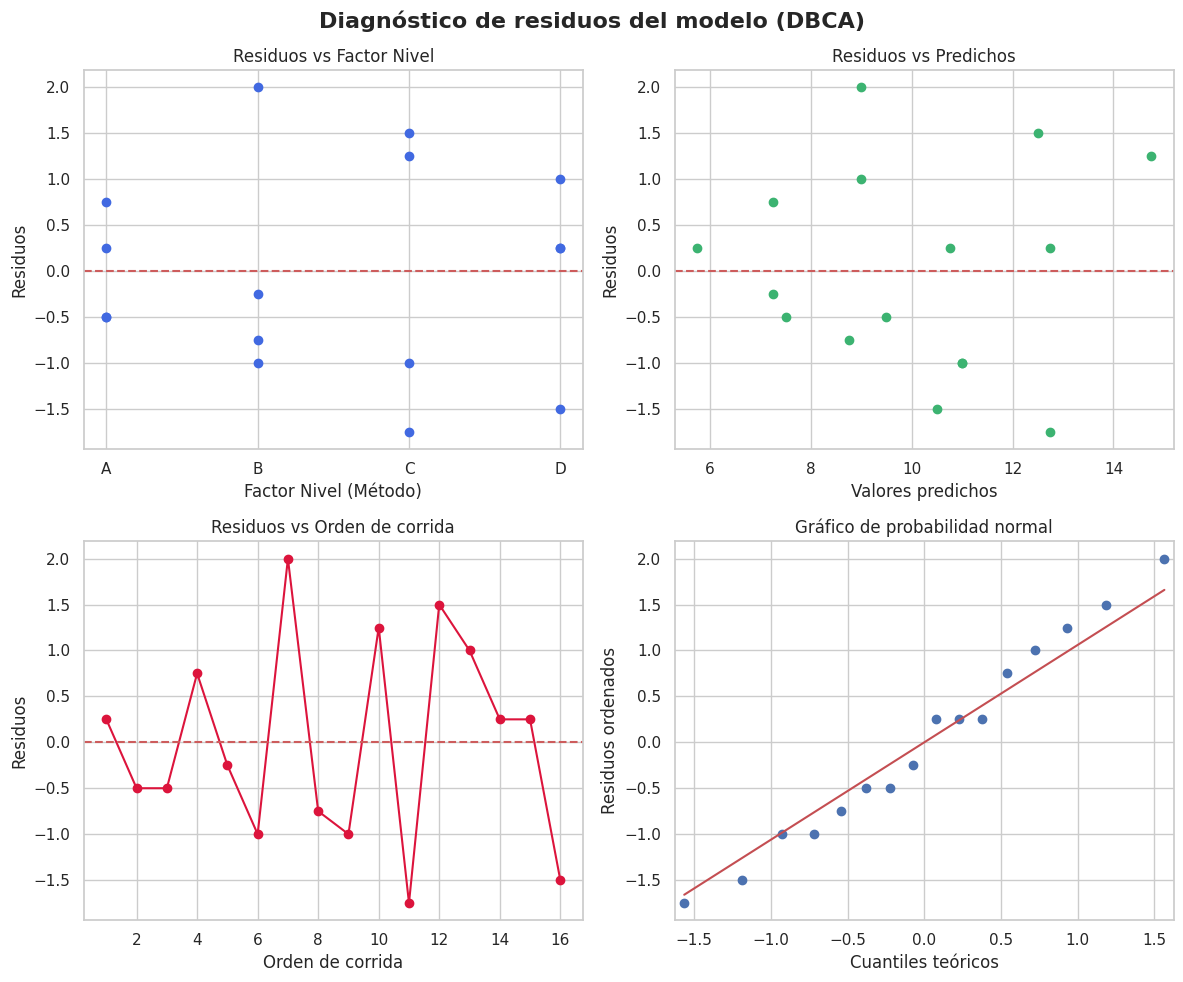

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. DATOS DEL EXPERIMENTO (Heredados del Ejercicio 1)
data = {
    'Operador': ['1', '2', '3', '4'] * 4,
    'Metodo': ['A']*4 + ['B']*4 + ['C']*4 + ['D']*4,
    'Tiempo': [
        6, 9, 7, 8,    # Método A
        7, 10, 11, 8,  # Método B
        10, 16, 11, 14,# Método C
        10, 13, 11, 9  # Método D
    ]
}
df = pd.DataFrame(data)

# Ajustamos el modelo lineal (ANOVA) para poder extraer los residuos y valores predichos
modelo = ols('Tiempo ~ C(Metodo) + C(Operador)', data=df).fit()

# --- SECCIÓN 2: PRUEBA DE TUKEY HSD ---
print("--- PRUEBA DE TUKEY HSD PARA TRATAMIENTOS (MÉTODOS) ---")
# Calculamos Tukey con un alpha de 0.05
tukey = pairwise_tukeyhsd(endog=df['Tiempo'], groups=df['Metodo'], alpha=0.05)
print(tukey)
print("\nNota: Revisa la columna 'reject' (True/False). True indica una diferencia significativa, ")
print("que en este caso corresponderá únicamente a la pareja A vs C, coincidiendo con la imagen.")


# --- SECCIÓN 3: DIAGNÓSTICO DE RESIDUOS DEL MODELO (DBCA) ---
residuos = modelo.resid
predichos = modelo.fittedvalues

# Configurar el lienzo para los 4 gráficos
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Diagnóstico de residuos del modelo (DBCA)', fontsize=16, fontweight='bold')

# 1. Residuos vs Factor Nivel (Método)
axs[0, 0].scatter(df['Metodo'], residuos, color='royalblue')
axs[0, 0].axhline(0, color='indianred', linestyle='--')
axs[0, 0].set_title('Residuos vs Factor Nivel')
axs[0, 0].set_xlabel('Factor Nivel (Método)')
axs[0, 0].set_ylabel('Residuos')

# 2. Residuos vs Predichos
axs[0, 1].scatter(predichos, residuos, color='mediumseagreen')
axs[0, 1].axhline(0, color='indianred', linestyle='--')
axs[0, 1].set_title('Residuos vs Predichos')
axs[0, 1].set_xlabel('Valores predichos')
axs[0, 1].set_ylabel('Residuos')

# 3. Residuos vs Orden de corrida
orden_corrida = np.arange(1, len(residuos) + 1)
axs[1, 0].plot(orden_corrida, residuos, marker='o', color='crimson', linestyle='-')
axs[1, 0].axhline(0, color='indianred', linestyle='--')
axs[1, 0].set_title('Residuos vs Orden de corrida')
axs[1, 0].set_xlabel('Orden de corrida')
axs[1, 0].set_ylabel('Residuos')

# 4. Gráfico de probabilidad normal (Q-Q plot)
# Usamos statsmodels para generar el Q-Q plot de manera sencilla
sm.qqplot(residuos, line='s', ax=axs[1, 1], color='purple')
axs[1, 1].set_title('Gráfico de probabilidad normal')
axs[1, 1].set_xlabel('Cuantiles teóricos')
axs[1, 1].set_ylabel('Residuos ordenados')

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Ajustar para que el título principal no se sobreponga
plt.show()